# 🤖 Customer Churn — Modelling v4
**Kaggle Playground Series 2026**

Changes vs v3:
- Correlated features resolved — one representative per group
- 40 features → 13 clean features
- Decision: keep Contract + contract_x_tenure, drop tenure standalone

### Feature groups
- Tenure/Contract : Contract, contract_x_tenure
- Internet        : InternetService, charge_x_fiber
- Charges         : avg_monthly_charge, charge_per_addon
- Payment         : pm_electronic_check, payment_type, PaperlessBilling
- Add-ons         : num_protective_addons, num_streaming_addons
- Demographics    : is_solo, SeniorCitizen

### Structure
1. Setup & Load
2. Feature selection
3. LightGBM — 5-fold CV
4. OOF Analysis
5. Feature Importance
6. Submission

---
## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED    = 42
N_FOLDS = 5

DATA_DIR = "/Users/clairedebadts/kaggle/customer-churn/data/processed/"
OUT_DIR  = "/Users/clairedebadts/kaggle/customer-churn/"

X_train  = pd.read_csv(DATA_DIR + "X_train.csv")
y_train  = pd.read_csv(DATA_DIR + "y_train.csv").squeeze()
X_test   = pd.read_csv(DATA_DIR + "X_test.csv")
test_ids = pd.read_csv(DATA_DIR + "test_ids.csv")

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}  |  churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test  : {X_test.shape}")


X_train : (594194, 41)
y_train : (594194,)  |  churn rate: 22.52%
X_test  : (254655, 41)


---
## 2. Feature Selection

13 features — one representative per correlated group.


In [2]:
V4_FEATURES = ['Contract', 'contract_x_tenure', 'InternetService', 'charge_x_fiber', 'avg_monthly_charge', 'charge_per_addon', 'pm_electronic_check', 'payment_type', 'PaperlessBilling', 'num_protective_addons', 'num_streaming_addons', 'is_solo', 'SeniorCitizen']

missing = [f for f in V4_FEATURES if f not in X_train.columns]
print(f"Missing features : {missing if missing else 'None ✅'}")

X_train = X_train[V4_FEATURES]
X_test  = X_test[V4_FEATURES]

FEATURE_COLS = X_train.columns.tolist()
print(f"Features         : {len(FEATURE_COLS)}")
print()
for f in FEATURE_COLS:
    print(f"  {f}")


Missing features : None ✅
Features         : 13

  Contract
  contract_x_tenure
  InternetService
  charge_x_fiber
  avg_monthly_charge
  charge_per_addon
  pm_electronic_check
  payment_type
  PaperlessBilling
  num_protective_addons
  num_streaming_addons
  is_solo
  SeniorCitizen


---
## 3. LightGBM — 5-Fold CV

In [3]:
params = {
    'objective'         : 'binary',
    'metric'            : 'auc',
    'learning_rate'     : 0.05,
    'num_leaves'        : 31,
    'max_depth'         : 6,
    'min_child_samples' : 50,
    'feature_fraction'  : 0.8,
    'bagging_fraction'  : 0.8,
    'bagging_freq'      : 5,
    'lambda_l1'         : 0.1,
    'lambda_l2'         : 1.0,
    'is_unbalance'      : True,
    'verbose'           : -1,
    'random_state'      : SEED,
}

skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds = np.zeros(len(X_train))
tst_preds = np.zeros(len(X_test))
scores    = []
gain_imp  = np.zeros(len(FEATURE_COLS))
split_imp = np.zeros(len(FEATURE_COLS))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=100),
        ],
    )

    oof_preds[val_idx] = model.predict(X_val)
    tst_preds         += model.predict(X_test) / N_FOLDS
    gain_imp          += model.feature_importance(importance_type='gain')  / N_FOLDS
    split_imp         += model.feature_importance(importance_type='split') / N_FOLDS

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    scores.append(fold_auc)
    print(f"  Fold {fold} — AUC: {fold_auc:.5f} | best iter: {model.best_iteration}")

auc_final = roc_auc_score(y_train, oof_preds)
print(f"\n  OOF AUC  : {auc_final:.5f}")
print(f"  Mean     : {np.mean(scores):.5f} +/- {np.std(scores):.5f}")
print(f"  vs v1    : {auc_final - 0.91622:+.5f}")
print(f"  vs v3    : {auc_final - 0.91627:+.5f}")


[100]	valid_0's auc: 0.901975
[200]	valid_0's auc: 0.902913
[300]	valid_0's auc: 0.903154
[400]	valid_0's auc: 0.903309
[500]	valid_0's auc: 0.903347
[600]	valid_0's auc: 0.903398
[700]	valid_0's auc: 0.903429
[800]	valid_0's auc: 0.903428
  Fold 1 — AUC: 0.90346 | best iter: 753
[100]	valid_0's auc: 0.903155
[200]	valid_0's auc: 0.904154
[300]	valid_0's auc: 0.904446
[400]	valid_0's auc: 0.904603
[500]	valid_0's auc: 0.904704
[600]	valid_0's auc: 0.904734
[700]	valid_0's auc: 0.904759
[800]	valid_0's auc: 0.904776
  Fold 2 — AUC: 0.90479 | best iter: 751
[100]	valid_0's auc: 0.903016
[200]	valid_0's auc: 0.903885
[300]	valid_0's auc: 0.904289
[400]	valid_0's auc: 0.904406
[500]	valid_0's auc: 0.904439
[600]	valid_0's auc: 0.904532
[700]	valid_0's auc: 0.904518
  Fold 3 — AUC: 0.90454 | best iter: 665
[100]	valid_0's auc: 0.904311
[200]	valid_0's auc: 0.905156
[300]	valid_0's auc: 0.90544
[400]	valid_0's auc: 0.905569
[500]	valid_0's auc: 0.905699
[600]	valid_0's auc: 0.905743
[700]	va

---
## 4. OOF Analysis

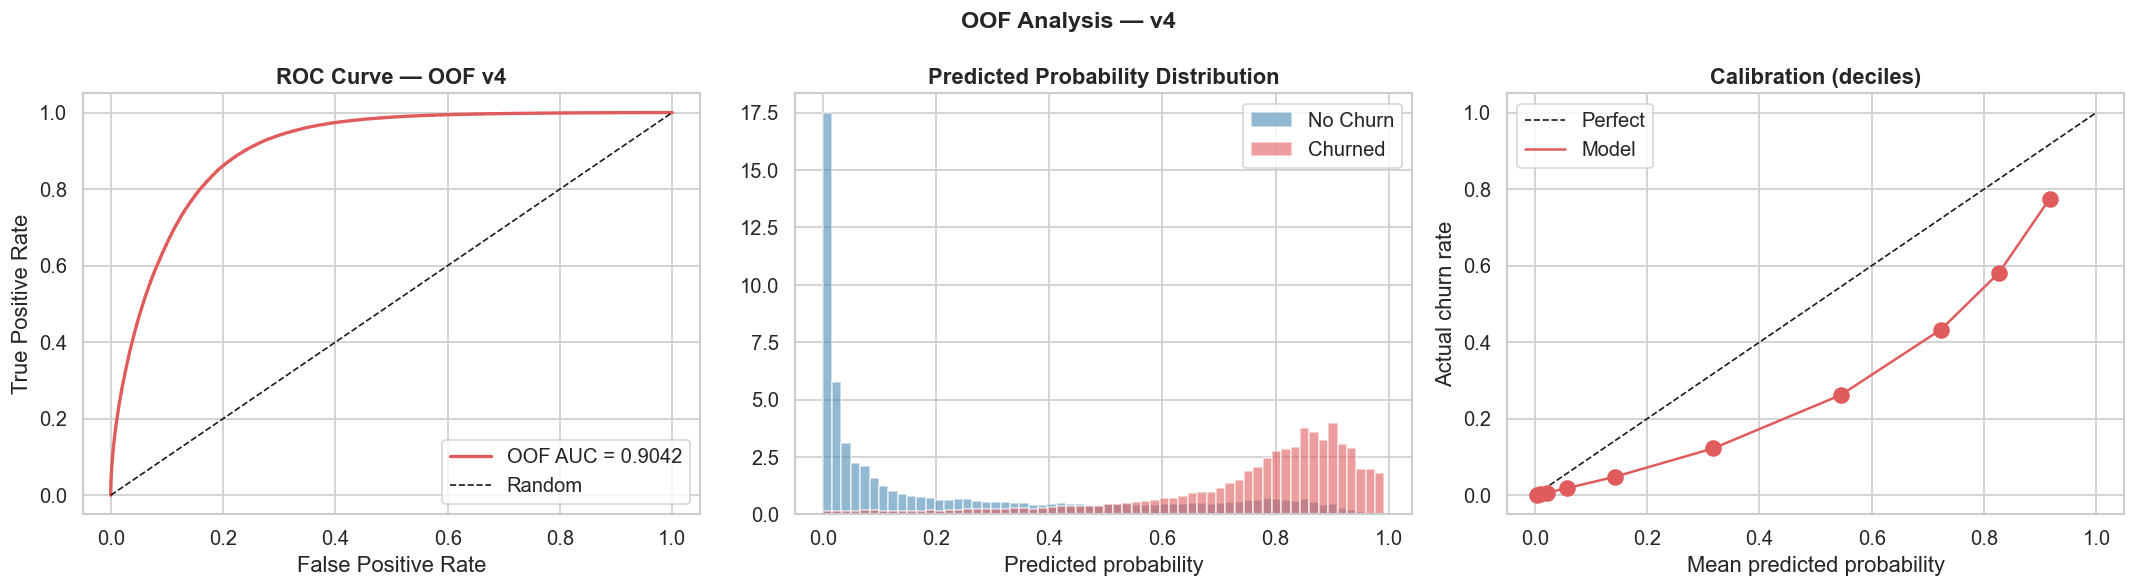

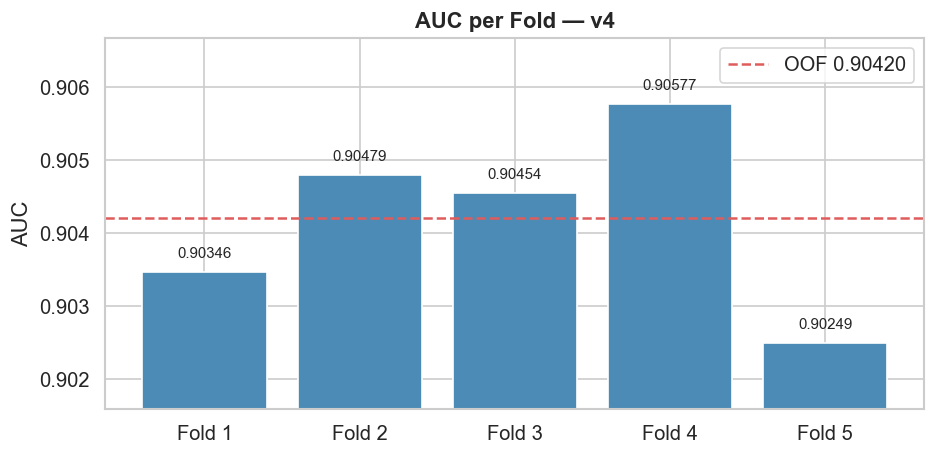

Fold std : 0.00113
Max-Min  : 0.00328


In [4]:
fpr, tpr, _ = roc_curve(y_train, oof_preds)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, color='#E05C5C', linewidth=2,
             label=f'OOF AUC = {auc_final:.4f}')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_title('ROC Curve — OOF v4', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].hist(oof_preds[y_train==0], bins=60, alpha=0.6,
             color='#4C8BB5', label='No Churn', density=True)
axes[1].hist(oof_preds[y_train==1], bins=60, alpha=0.6,
             color='#E05C5C', label='Churned', density=True)
axes[1].set_title('Predicted Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Predicted probability')
axes[1].legend()

oof_df = pd.DataFrame({'prob': oof_preds, 'actual': y_train})
oof_df['decile'] = pd.qcut(oof_df['prob'], q=10, labels=False)
calib = oof_df.groupby('decile').agg(
    mean_pred=('prob','mean'), actual_rate=('actual','mean')
).reset_index()
axes[2].plot([0,1],[0,1],'k--',linewidth=1,label='Perfect')
axes[2].scatter(calib['mean_pred'], calib['actual_rate'],
                color='#E05C5C', s=80, zorder=5)
axes[2].plot(calib['mean_pred'], calib['actual_rate'],
             color='#E05C5C', linewidth=1.5, label='Model')
axes[2].set_title('Calibration (deciles)', fontweight='bold')
axes[2].set_xlabel('Mean predicted probability')
axes[2].set_ylabel('Actual churn rate')
axes[2].legend()

plt.suptitle('OOF Analysis — v4', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'Fold {i}' for i in range(1, N_FOLDS+1)], scores,
              color='#4C8BB5', edgecolor='white')
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0002,
            f'{val:.5f}', ha='center', fontsize=9)
ax.axhline(auc_final, color='#E05C5C', linestyle='--',
           linewidth=1.5, label=f'OOF {auc_final:.5f}')
ax.set_title('AUC per Fold — v4', fontweight='bold')
ax.set_ylabel('AUC')
ax.set_ylim(min(scores)*0.999, max(scores)*1.001)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Fold std : {np.std(scores):.5f}")
print(f"Max-Min  : {max(scores)-min(scores):.5f}")


---
## 5. Feature Importance

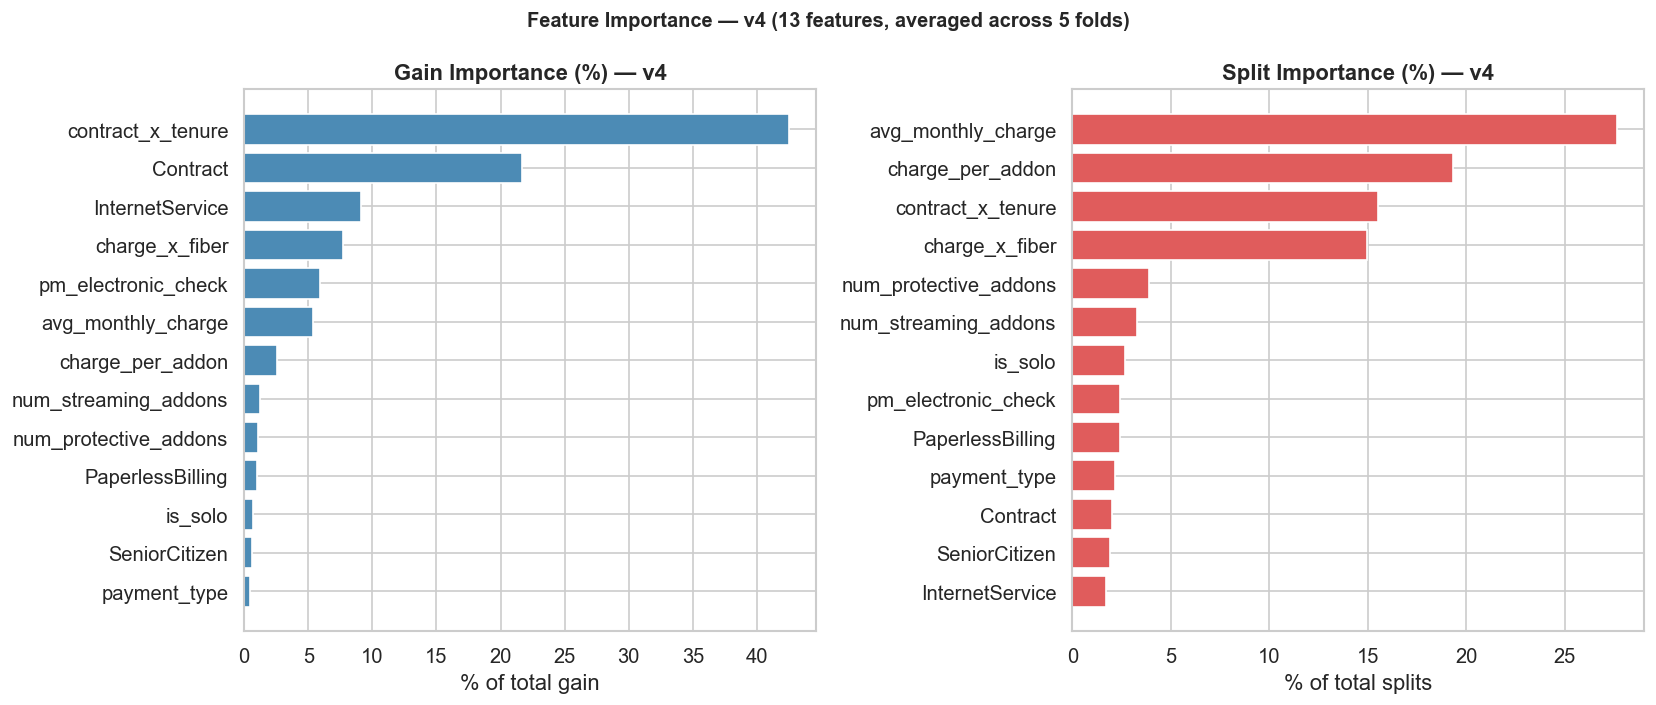

              feature  gain_norm  split_norm
    contract_x_tenure      42.51       15.54
             Contract      21.67        1.99
      InternetService       9.13        1.70
       charge_x_fiber       7.68       14.94
  pm_electronic_check       5.91        2.44
   avg_monthly_charge       5.38       27.67
     charge_per_addon       2.58       19.33
 num_streaming_addons       1.26        3.27
num_protective_addons       1.10        3.88
     PaperlessBilling       1.01        2.44
              is_solo       0.71        2.67
        SeniorCitizen       0.63        1.93
         payment_type       0.45        2.19


In [5]:
imp_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'gain_norm' : (gain_imp  / gain_imp.sum()  * 100).round(2),
    'split_norm': (split_imp / split_imp.sum() * 100).round(2),
}).sort_values('gain_norm', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(imp_df['feature'][::-1], imp_df['gain_norm'][::-1],
             color='#4C8BB5', edgecolor='white')
axes[0].set_title('Gain Importance (%) — v4', fontweight='bold')
axes[0].set_xlabel('% of total gain')

axes[1].barh(
    imp_df.sort_values('split_norm', ascending=False)['feature'][::-1],
    imp_df.sort_values('split_norm', ascending=False)['split_norm'][::-1],
    color='#E05C5C', edgecolor='white'
)
axes[1].set_title('Split Importance (%) — v4', fontweight='bold')
axes[1].set_xlabel('% of total splits')

plt.suptitle('Feature Importance — v4 (13 features, averaged across 5 folds)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(imp_df[['feature','gain_norm','split_norm']].to_string(index=False))


---
## 6. Submission

Sanity checks: ✅
Rows      : 254,655
Churn mean: 0.3494  (train: 0.2252)

Version comparison (OOF):
  v1 — 41 features + risk_score : 0.91622  | LB: 0.91398
  v2 — 15 features, no risk_score: 0.91565  | LB: 0.91328
  v3 — 40 features, no risk_score: 0.91627  | LB: pending
  v4 — 13 features, de-correlated: 0.90420  | LB: pending


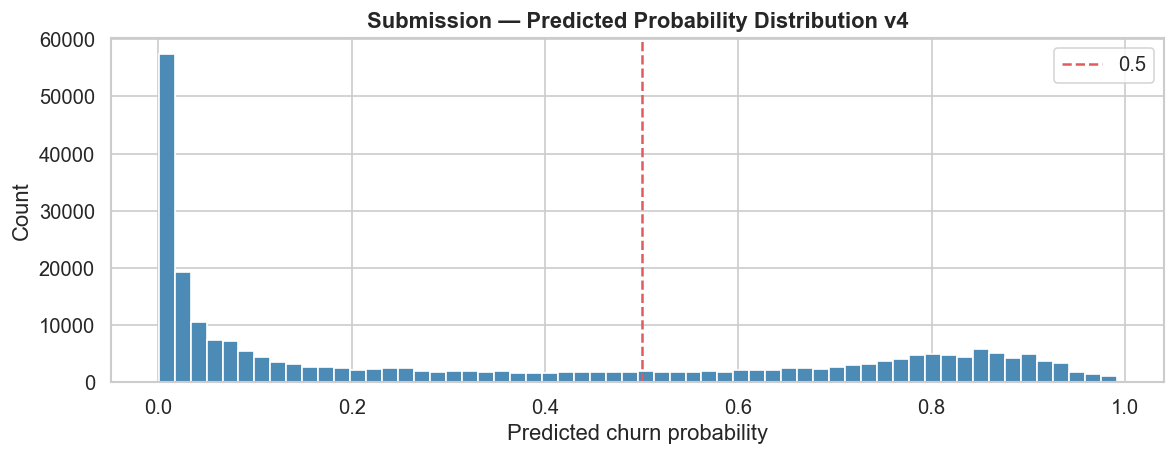


✅ Saved: /Users/clairedebadts/kaggle/customer-churn/submission.csv


In [6]:
import os

submission = pd.DataFrame({
    'id'   : test_ids['id'],
    'Churn': tst_preds
})

assert submission['id'].nunique() == len(submission)
assert submission['Churn'].between(0, 1).all()
assert submission.isnull().sum().sum() == 0
print("Sanity checks: ✅")
print(f"Rows      : {len(submission):,}")
print(f"Churn mean: {submission['Churn'].mean():.4f}  (train: {y_train.mean():.4f})")
print(f"\nVersion comparison (OOF):")
print(f"  v1 — 41 features + risk_score : 0.91622  | LB: 0.91398")
print(f"  v2 — 15 features, no risk_score: 0.91565  | LB: 0.91328")
print(f"  v3 — 40 features, no risk_score: 0.91627  | LB: pending")
print(f"  v4 — 13 features, de-correlated: {auc_final:.5f}  | LB: pending")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(submission['Churn'], bins=60, color='#4C8BB5', edgecolor='white')
ax.axvline(0.5, color='#E05C5C', linestyle='--', linewidth=1.5, label='0.5')
ax.set_title('Submission — Predicted Probability Distribution v4', fontweight='bold')
ax.set_xlabel('Predicted churn probability')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

os.makedirs(OUT_DIR, exist_ok=True)
submission.to_csv(OUT_DIR + "submission.csv", index=False)
print(f"\n✅ Saved: {OUT_DIR}submission.csv")
